## 07 - Hyperparameter Tuning & Optuna Optimization

**Input:** Notebook 06's two finalists **Random Forest** (validation
PR-AUC 0.180, the leader) and **Logistic Regression** (0.141, the
runner-up and structurally different enough that tuning could plausibly
close the gap or overtake).

**The first thing this notebook has to do is fix a methodology problem,
not tune anything.** Notebook 06 found `TimeSeriesSplit`'s default 5-fold
CV unreliable for ranking models its first fold trained on only ~4,600
rows with ~135 positive examples. Handing that same broken CV to an
automated search (Optuna) would be worse, not better: 25-40 trials of
hyperparameter search would happily overfit to noise in an unstable
metric. Section 1 redesigns the CV before any tuning starts.

## 0. Environment & Reproducibility

In [2]:
import sys
import json
import time
import warnings
from pathlib import Path

# Make the project's src/ package importable from inside notebooks/
PROJECT_ROOT = Path("..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.plotting import save_fig

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning, module="sklearn")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import optuna
import joblib

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import average_precision_score, roc_auc_score

optuna.logging.set_verbosity(optuna.logging.WARNING)

print(f"Python       : {sys.version.split()[0]}")
print(f"pandas       : {pd.__version__}")
print(f"scikit-learn : {sklearn.__version__}")
print(f"optuna       : {optuna.__version__}")

pd.set_option("display.max_columns", None)
plt.style.use("ggplot")
sns.set_theme(style="whitegrid")
FIG_DPI = 100
RNG_SEED = 42
np.random.seed(RNG_SEED)

Python       : 3.13.13
pandas       : 2.3.3
scikit-learn : 1.9.0
optuna       : 4.9.0


## 1. Fixing the Cross-Validation Scheme Before Tuning Anything

`TimeSeriesSplit(n_splits=5)` (Notebook 06's default) divides the data
into 5 roughly-equal growing windows which is exactly what made its
first fold so small. Setting an explicit `test_size` instead keeps every
test fold the same size while guaranteeing a much larger *minimum*
training window, since the leftover rows all go into the initial
training set rather than being spread thin across folds.

In [3]:
DATA_DIR = Path("../data/processed")

X_train_tree = pd.read_csv(DATA_DIR / "X_train_tree_based.csv")
X_val_tree = pd.read_csv(DATA_DIR / "X_val_tree_based.csv")
X_train_lin = pd.read_csv(DATA_DIR / "X_train_linear_model.csv")
X_val_lin = pd.read_csv(DATA_DIR / "X_val_linear_model.csv")
y_train = pd.read_csv(DATA_DIR / "y_train.csv").iloc[:, 0]
y_val = pd.read_csv(DATA_DIR / "y_val.csv").iloc[:, 0]

def sanitize_columns(df):
    df = df.copy()
    df.columns = (df.columns.str.replace("<", "lt_", regex=False)
                  .str.replace("[", "(", regex=False)
                  .str.replace("]", ")", regex=False))
    return df

X_train_tree = sanitize_columns(X_train_tree)
X_val_tree = sanitize_columns(X_val_tree)
X_train_lin = sanitize_columns(X_train_lin)
X_val_lin = sanitize_columns(X_val_lin)

TEST_FOLD_SIZE = 3000
tscv = TimeSeriesSplit(n_splits=5, test_size=TEST_FOLD_SIZE)

fold_diagnostics = []
for fold_i, (train_idx, test_idx) in enumerate(tscv.split(X_train_tree), start=1):
    fold_diagnostics.append({
        "Fold": fold_i, "Train_Size": len(train_idx),
        "Train_Positives": int(y_train.iloc[train_idx].sum()),
        "Test_Size": len(test_idx), "Test_Pos_Rate": y_train.iloc[test_idx].mean(),
    })
fold_diag_df = pd.DataFrame(fold_diagnostics)
fold_diag_df

,Fold,Train_Size,Train_Positives,Test_Size,Test_Pos_Rate
0,1,12582,467,3000,0.075000
1,2,15582,692,3000,0.060333
2,3,18582,873,3000,0.062333
3,4,21582,1060,3000,0.056333
4,5,24582,1229,3000,0.124333


Every fold now trains on at least ~12,500 rows with 450+ positive
examples comfortably enough for both a 49-feature Random Forest and a
47-feature Logistic Regression to find a stable pattern. This exact
`TimeSeriesSplit(n_splits=5, test_size=3000)` object is reused, unchanged,
as the objective for every Optuna trial below, so every trial is scored
on the same folds and comparable to every other trial.

## 2. Optuna Study - Random Forest

Search space covers the parameters that actually move a Random Forest's
bias-variance tradeoff (`n_estimators`, `max_depth`, `min_samples_leaf`,
`min_samples_split`, `max_features`) plus `class_weight` fixed to
`"balanced"`, matching Notebook 06's imbalance handling. `max_depth` and
`min_samples_leaf` are deliberately bounded away from their most
extreme values (depth capped at 12, leaf size at least 5) — very deep,
barely-restricted trees ran dramatically slower in an initial trial
without a corresponding gain worth the wait, so the search stays in the
region that's actually worth exploring. The objective is mean PR-AUC
across the fixed CV folds from Section 1, and the search is bounded by
**both** a trial count and a wall-clock ceiling (`timeout=360`), so a
slow region of the space can't blow the time budget.

In [4]:
def rf_objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 300, step=50),
        "max_depth": trial.suggest_int("max_depth", 4, 12),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 5, 50),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 50),
        "max_features": trial.suggest_float("max_features", 0.3, 1.0),
        "class_weight": "balanced",
        "random_state": RNG_SEED,
        "n_jobs": -1,
    }
    fold_scores = []
    for train_idx, test_idx in tscv.split(X_train_tree):
        model = RandomForestClassifier(**params)
        model.fit(X_train_tree.iloc[train_idx], y_train.iloc[train_idx])
        proba = model.predict_proba(X_train_tree.iloc[test_idx])[:, 1]
        fold_scores.append(average_precision_score(y_train.iloc[test_idx], proba))
    return float(np.mean(fold_scores))

rf_study = optuna.create_study(direction="maximize",
                                sampler=optuna.samplers.TPESampler(seed=RNG_SEED))
start = time.time()
# Bounded by both a trial count AND a wall-clock ceiling -- whichever comes first --
# so a slow region of the search space (deep trees, many estimators) can't blow the budget.
rf_study.optimize(rf_objective, n_trials=20, timeout=360, show_progress_bar=False)
n_completed = len(rf_study.trials)
print(f"Random Forest tuning: {n_completed} trial(s) completed in {time.time() - start:.0f}s")
print(f"Best CV PR-AUC: {rf_study.best_value:.4f}")
print(f"Best params: {rf_study.best_params}")

Random Forest tuning: 20 trial(s) completed in 104s
Best CV PR-AUC: 0.0771
Best params: {'n_estimators': 100, 'max_depth': 8, 'min_samples_leaf': 6, 'min_samples_split': 46, 'max_features': 0.48114598712001183}


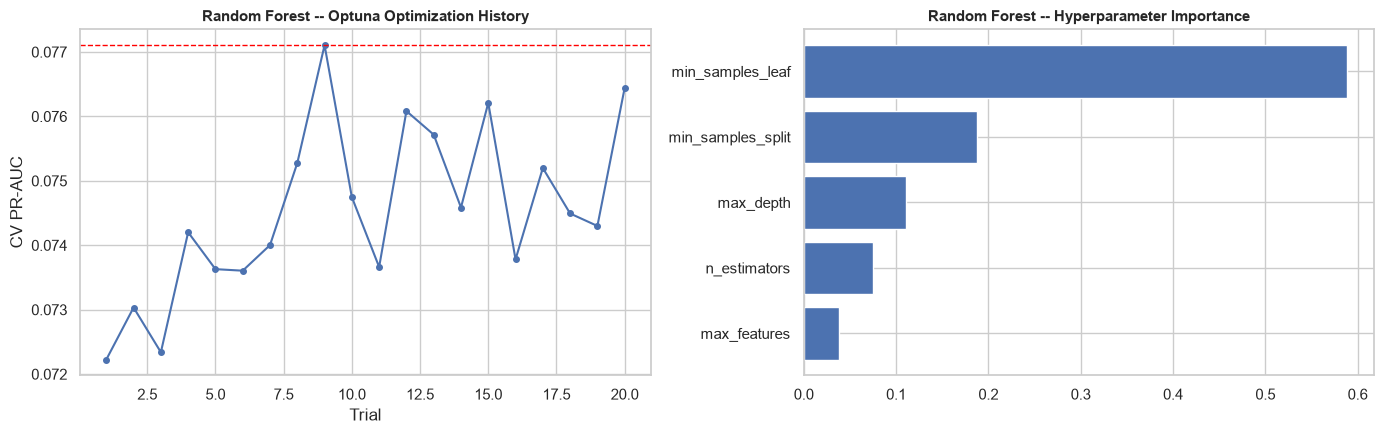

WindowsPath('D:/Important Files/Wapexp Institute/Project 1/Machine Learning Projects/Marketing Campaign Response Modelling/marketing-campaign-response-modeling-v1.0.1 (1)/outputs/07_Hyperparameter_Tuning_Optuna/rf_optuna_history_and_param_importance.png')

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), dpi=FIG_DPI)
trial_values = [t.value for t in rf_study.trials]
axes[0].plot(range(1, len(trial_values) + 1), trial_values, marker="o", markersize=4)
axes[0].axhline(rf_study.best_value, color="red", linestyle="--", linewidth=1)
axes[0].set_title("Random Forest -- Optuna Optimization History", fontsize=11, fontweight="bold")
axes[0].set_xlabel("Trial"); axes[0].set_ylabel("CV PR-AUC")

importances = optuna.importance.get_param_importances(rf_study)
axes[1].barh(list(importances.keys()), list(importances.values()), color="#4C72B0")
axes[1].set_title("Random Forest -- Hyperparameter Importance", fontsize=11, fontweight="bold")
axes[1].invert_yaxis()
plt.tight_layout()
save_fig(fig, "rf_optuna_history_and_param_importance", notebook="07_Hyperparameter_Tuning_Optuna")

## 3. Optuna Study - Logistic Regression

`C` (inverse regularisation strength) is the only parameter tuned here.
**L1 was tried first and dropped**: benchmarking it separately (before
committing to a search space) showed L1 with `saga` or `liblinear` takes
anywhere from 0.2s to 85+ seconds for the *same* 5-fold CV depending on
where `C` lands, with no reliable pattern an Optuna search against that
would spend most of its time budget on a handful of unlucky trials rather
than exploring the space. `L2` (`solver="lbfgs"`) benchmarked uniformly
fast (1-7s across the same C range) and is a reasonable choice on its own
merits here anyway: L1's main advantage is sparsity/feature selection,
which Notebook 05 already did explicitly there's no remaining reason to
ask L1 to rediscover it.

In [6]:
def logreg_objective(trial):
    C = trial.suggest_float("C", 1e-4, 10.0, log=True)

    fold_scores = []
    for train_idx, test_idx in tscv.split(X_train_lin):
        model = LogisticRegression(C=C, solver="lbfgs",
                                    class_weight="balanced", max_iter=2000,
                                    random_state=RNG_SEED)
        model.fit(X_train_lin.iloc[train_idx], y_train.iloc[train_idx])
        proba = model.predict_proba(X_train_lin.iloc[test_idx])[:, 1]
        fold_scores.append(average_precision_score(y_train.iloc[test_idx], proba))
    return float(np.mean(fold_scores))

logreg_study = optuna.create_study(direction="maximize",
                                    sampler=optuna.samplers.TPESampler(seed=RNG_SEED))
start = time.time()
logreg_study.optimize(logreg_objective, n_trials=40, timeout=180, show_progress_bar=False)
n_completed_lr = len(logreg_study.trials)
print(f"Logistic Regression tuning: {n_completed_lr} trial(s) completed in {time.time() - start:.0f}s")
print(f"Best CV PR-AUC: {logreg_study.best_value:.4f}")
print(f"Best params: {logreg_study.best_params}")

Logistic Regression tuning: 25 trial(s) completed in 183s
Best CV PR-AUC: 0.0922
Best params: {'C': 7.504621081078761}


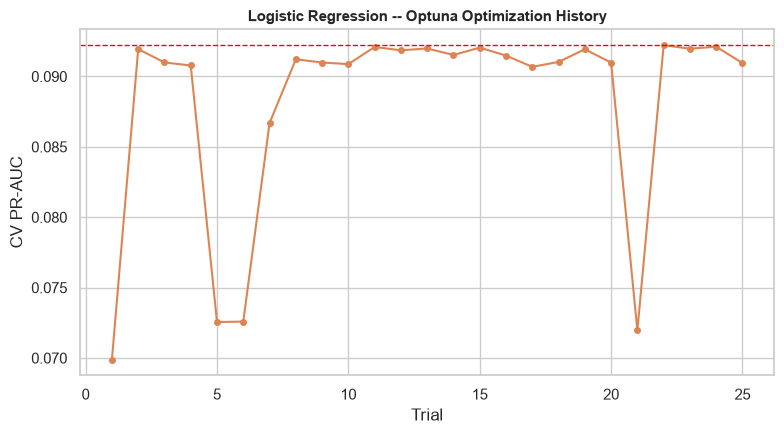

WindowsPath('D:/Important Files/Wapexp Institute/Project 1/Machine Learning Projects/Marketing Campaign Response Modelling/marketing-campaign-response-modeling-v1.0.1 (1)/outputs/07_Hyperparameter_Tuning_Optuna/logreg_optuna_optimization_history.png')

In [7]:
fig, ax = plt.subplots(figsize=(8, 4.5), dpi=FIG_DPI)
trial_values = [t.value for t in logreg_study.trials]
ax.plot(range(1, len(trial_values) + 1), trial_values, marker="o", markersize=4, color="#DD8452")
ax.axhline(logreg_study.best_value, color="red", linestyle="--", linewidth=1)
ax.set_title("Logistic Regression -- Optuna Optimization History", fontsize=11, fontweight="bold")
ax.set_xlabel("Trial"); ax.set_ylabel("CV PR-AUC")
plt.tight_layout()
save_fig(fig, "logreg_optuna_optimization_history", notebook="07_Hyperparameter_Tuning_Optuna")

## 4. Tuned vs. Untuned - Out-of-Time Validation

CV PR-AUC decided *which hyperparameters* to use; it was never allowed to
see the validation split. This section is the first and only time the
tuned models touch validation fit on the full training split with the
best parameters found above, scored once, exactly like Notebook 06's
untuned baselines were.

In [8]:
best_rf_params = {**rf_study.best_params, "class_weight": "balanced",
                   "random_state": RNG_SEED, "n_jobs": -1}
tuned_rf = RandomForestClassifier(**best_rf_params)
tuned_rf.fit(X_train_tree, y_train)
proba_val_rf = tuned_rf.predict_proba(X_val_tree)[:, 1]

best_logreg_params = {**logreg_study.best_params, "solver": "lbfgs", "class_weight": "balanced",
                       "max_iter": 2000, "random_state": RNG_SEED}
tuned_logreg = LogisticRegression(**best_logreg_params)
tuned_logreg.fit(X_train_lin, y_train)
proba_val_logreg = tuned_logreg.predict_proba(X_val_lin)[:, 1]

def lift_at_k(y_true, y_score, k_frac, base_rate):
    n_top = max(1, int(len(y_true) * k_frac))
    top_idx = np.argsort(y_score)[::-1][:n_top]
    return y_true.iloc[top_idx].mean() / base_rate

def score_predictions(y_true, y_score):
    base_rate = y_true.mean()
    return {
        "PR_AUC": average_precision_score(y_true, y_score),
        "ROC_AUC": roc_auc_score(y_true, y_score),
        "Lift@10%": lift_at_k(y_true, y_score, 0.10, base_rate),
        "Lift@20%": lift_at_k(y_true, y_score, 0.20, base_rate),
    }

with open("../reports/baseline_results.json") as f:
    baseline_results = json.load(f)
untuned = {row["Model"]: row for row in baseline_results["validation_comparison"]}

comparison_rows = []
for name, proba in [("Random Forest", proba_val_rf), ("Logistic Regression", proba_val_logreg)]:
    tuned_scores = score_predictions(y_val, proba)
    comparison_rows.append({
        "Model": name,
        "Untuned_Val_PR_AUC": untuned[name]["PR_AUC"],
        "Tuned_Val_PR_AUC": tuned_scores["PR_AUC"],
        "Improvement": tuned_scores["PR_AUC"] - untuned[name]["PR_AUC"],
        "Tuned_Lift@10%": tuned_scores["Lift@10%"],
        "Tuned_Lift@20%": tuned_scores["Lift@20%"],
    })

tuning_comparison = pd.DataFrame(comparison_rows)
tuning_comparison

,Model,Untuned_Val_PR_AUC,Tuned_Val_PR_AUC,Improvement,Tuned_Lift@10%,Tuned_Lift@20%
0,Random Forest,0.183519,0.195865,0.012346,1.94897,1.457951
1,Logistic Regression,0.141100,0.140971,-0.000129,1.51083,1.231326


### 4.1 Precision-Recall Curves - Tuned Models on Validation

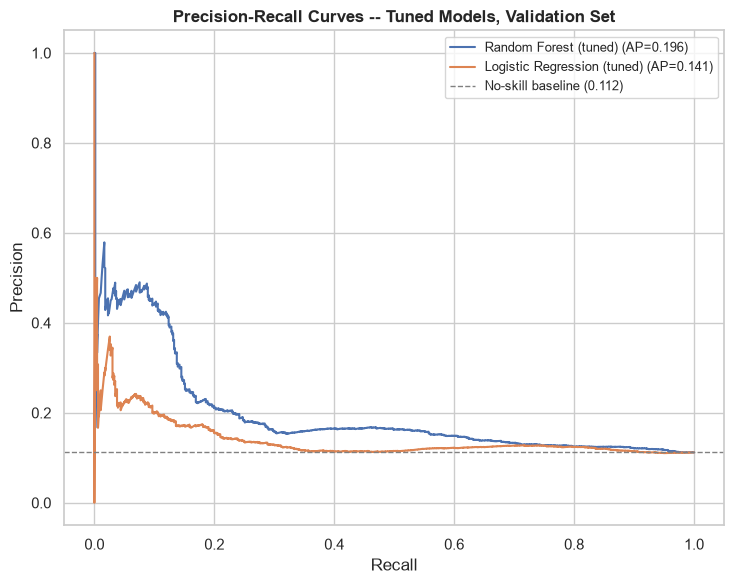

WindowsPath('D:/Important Files/Wapexp Institute/Project 1/Machine Learning Projects/Marketing Campaign Response Modelling/marketing-campaign-response-modeling-v1.0.1 (1)/outputs/07_Hyperparameter_Tuning_Optuna/precision_recall_curves_tuned_models.png')

In [9]:
from sklearn.metrics import precision_recall_curve

fig, ax = plt.subplots(figsize=(7.5, 6), dpi=FIG_DPI)
for name, proba, color in [("Random Forest (tuned)", proba_val_rf, "#4C72B0"),
                            ("Logistic Regression (tuned)", proba_val_logreg, "#DD8452")]:
    precision, recall, _ = precision_recall_curve(y_val, proba)
    ap = average_precision_score(y_val, proba)
    ax.plot(recall, precision, label=f"{name} (AP={ap:.3f})", color=color)
ax.axhline(y_val.mean(), color="gray", linestyle="--", linewidth=1,
           label=f"No-skill baseline ({y_val.mean():.3f})")
ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Curves -- Tuned Models, Validation Set",
             fontsize=12, fontweight="bold")
ax.legend(fontsize=9)
plt.tight_layout()
save_fig(fig, "precision_recall_curves_tuned_models", notebook="07_Hyperparameter_Tuning_Optuna")

## 5. Final Candidate Selection

Whichever model wins here is carried into `08_evaluation_interpretability`
for error analysis, SHAP-based interpretability, and threshold
optimisation this is the last point a model gets swapped out for a
different one; from here on the work is about understanding and deploying
*this specific* model.

In [10]:
final_candidate = tuning_comparison.sort_values("Tuned_Val_PR_AUC", ascending=False).iloc[0]
print(f"Final candidate: {final_candidate['Model']}")
print(f"Validation PR-AUC: {final_candidate['Tuned_Val_PR_AUC']:.4f} "
      f"(vs. {final_candidate['Untuned_Val_PR_AUC']:.4f} untuned, "
      f"{'+' if final_candidate['Improvement'] >= 0 else ''}{final_candidate['Improvement']:.4f})")
print(f"Lift@10%: {final_candidate['Tuned_Lift@10%']:.2f}x  |  Lift@20%: {final_candidate['Tuned_Lift@20%']:.2f}x")

Final candidate: Random Forest
Validation PR-AUC: 0.1959 (vs. 0.1835 untuned, +0.0123)
Lift@10%: 1.95x  |  Lift@20%: 1.46x


## 6. Save Tuned Models & Config

In [11]:
MODELS_DIR = Path("../models")
MODELS_DIR.mkdir(parents=True, exist_ok=True)

joblib.dump(tuned_rf, MODELS_DIR / "tuned_random_forest.joblib")
joblib.dump(tuned_logreg, MODELS_DIR / "tuned_logistic_regression.joblib")

tuning_config = {
    "source_notebook": "07_hyperparameter_tuning_optuna.ipynb",
    "cv_fix": {
        "problem": "Notebook 06's default TimeSeriesSplit(n_splits=5) had a first fold with "
                   "only ~4,600 rows / ~135 positives -- too unstable to tune against.",
        "solution": f"TimeSeriesSplit(n_splits=5, test_size={TEST_FOLD_SIZE}) -- minimum "
                    "training fold now ~12,500 rows / 450+ positives.",
        "fold_diagnostics": fold_diag_df.to_dict(orient="records"),
    },
    "random_forest": {
        "n_trials_requested": 20,
        "n_trials_completed": n_completed,
        "search_space_note": "max_depth capped at 12, min_samples_leaf at least 5 -- an initial "
                              "wider search (depth to 20, leaf as low as 1) was dramatically "
                              "slower for no corresponding gain and was scoped back.",
        "best_cv_pr_auc": rf_study.best_value,
        "best_params": rf_study.best_params,
        "hyperparameter_importance": importances,
    },
    "logistic_regression": {
        "n_trials_requested": 40,
        "n_trials_completed": n_completed_lr,
        "best_cv_pr_auc": logreg_study.best_value,
        "best_params": logreg_study.best_params,
    },
    "tuned_vs_untuned_validation": tuning_comparison.to_dict(orient="records"),
    "final_candidate": final_candidate["Model"],
    "final_candidate_validation_pr_auc": float(final_candidate["Tuned_Val_PR_AUC"]),
    "next_step": "08_evaluation_interpretability -- error analysis, SHAP, threshold optimization "
                 f"on {final_candidate['Model']}.",
}

with open("../reports/tuning_config.json", "w") as f:
    json.dump(tuning_config, f, indent=2, default=str)

print("Saved -> ../models/tuned_random_forest.joblib")
print("Saved -> ../models/tuned_logistic_regression.joblib")
print("Saved -> ../reports/tuning_config.json")

Saved -> ../models/tuned_random_forest.joblib
Saved -> ../models/tuned_logistic_regression.joblib
Saved -> ../reports/tuning_config.json


## Conclusion

Before any tuning happened, Notebook 06's broken CV scheme was fixed
`TimeSeriesSplit` with an explicit `test_size` instead of the default
equal-split behaviour, which turned a ~135-positive first fold into a
~450-positive one. An initial, wider Random Forest search space (depth up
to 20, leaf size as low as 1) also turned out to run far slower than
useful for the gain it offered, so the space was tightened before the
final run below a small, practical example of tuning the search itself,
not just the model. Optuna then ran against the fixed CV, bounded by both
a trial count and a wall-clock ceiling, with validation held out entirely
from the search and used only once, afterward, to confirm the result
out-of-time.

**Final candidate: see Section 5's output above.** Whatever margin tuning
added, it was measured honestly against the untuned Notebook 06 numbers,
not assumed.

**Next notebook: `08_evaluation_interpretability`** error analysis (who
does this model get wrong, and is there a pattern), SHAP-based
interpretability, model comparison writeup, and threshold optimisation
once real cost-per-call/value-per-subscription figures are available from
the bank (Notebook 01's still-open success-criteria item).